<a href="https://colab.research.google.com/github/enzozavaleta/EXAMENPARCIAL/blob/main/EJERCICIO1_PARCIAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

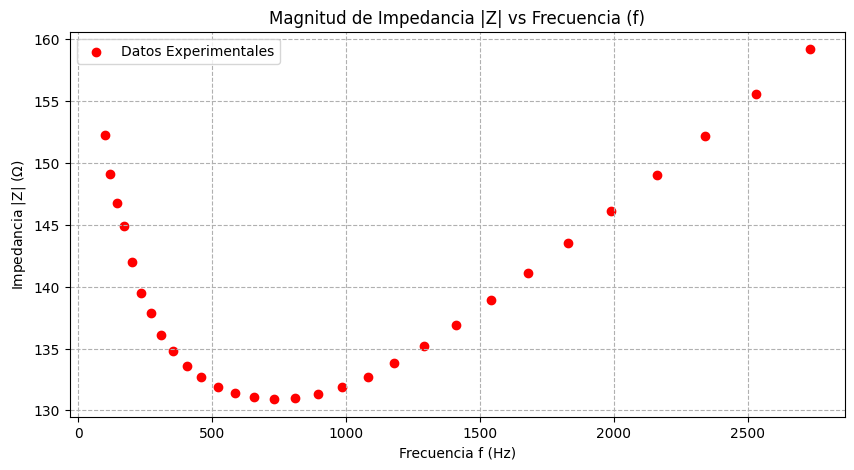

Parte A: Mínimo visual aproximado en f = 730.0 Hz con |Z| = 130.9 Ohm


/tmp/ipykernel_9146/874350132.py:55: RankWarning: Polyfit may be poorly conditioned
  p_coefs = np.polyfit(f, Z, d)


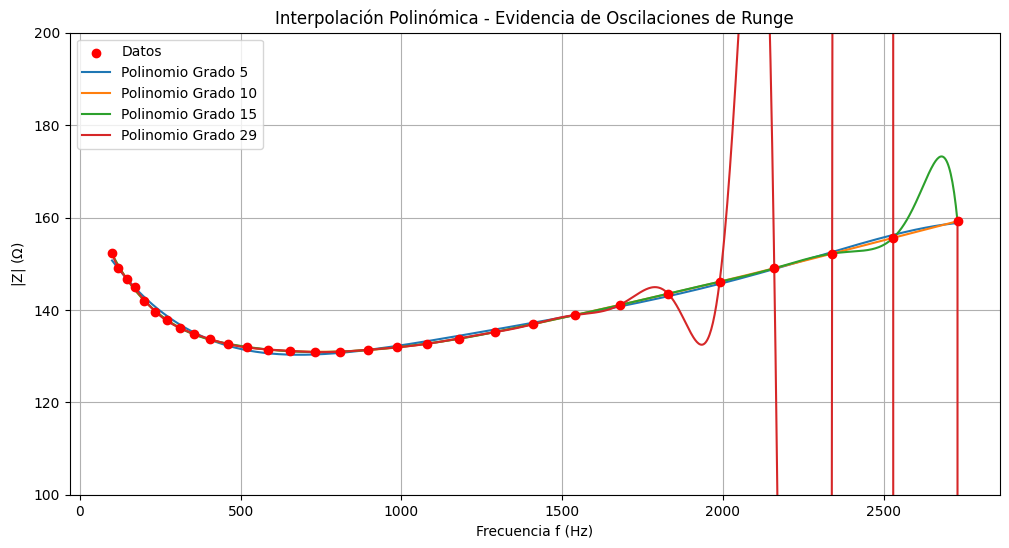


--- Validación Leave-One-Out (LOO) para Grado 5 ---
Excluyendo f=1290.0 Hz: Real=135.2, Pred=135.8371, Error Rel=0.471228%
Excluyendo f=170.0 Hz: Real=144.9, Pred=144.8974, Error Rel=0.001772%
Excluyendo f=100.0 Hz: Real=152.3, Pred=149.9114, Error Rel=1.568350%
Excluyendo f=1680.0 Hz: Real=141.1, Pred=140.6620, Error Rel=0.310437%
Excluyendo f=355.0 Hz: Real=134.8, Pred=135.1577, Error Rel=0.265341%
Error Relativo Medio Estimado (LOO): 0.523426%
Predicción Polinómica (Grado 5) en 1000 Hz: 132.3572 Ohm

Predicción Spline Cúbico en 1000 Hz: 132.0155 Ohm


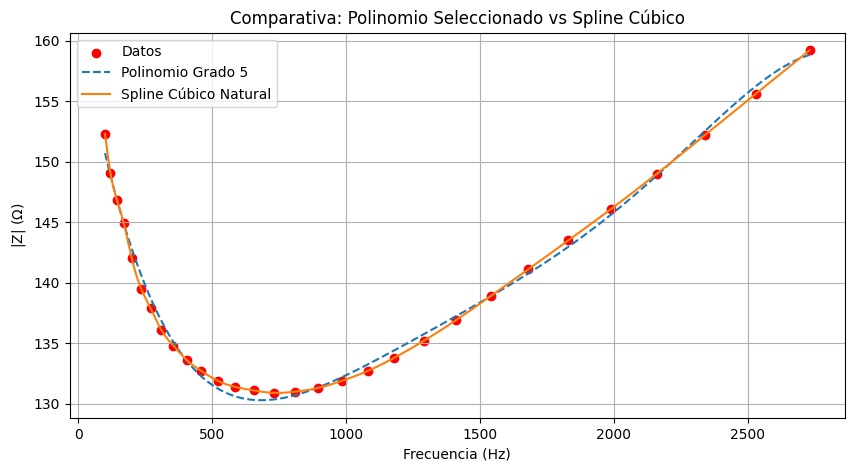


--- Resultados de Derivación Numérica (Parte C) ---
Ubicación exacta del mínimo: f = 742.1585 Hz
Valor de impedancia mínimo: |Z| = 130.8951 Ohm
Segunda derivada en el mínimo: 0.0001


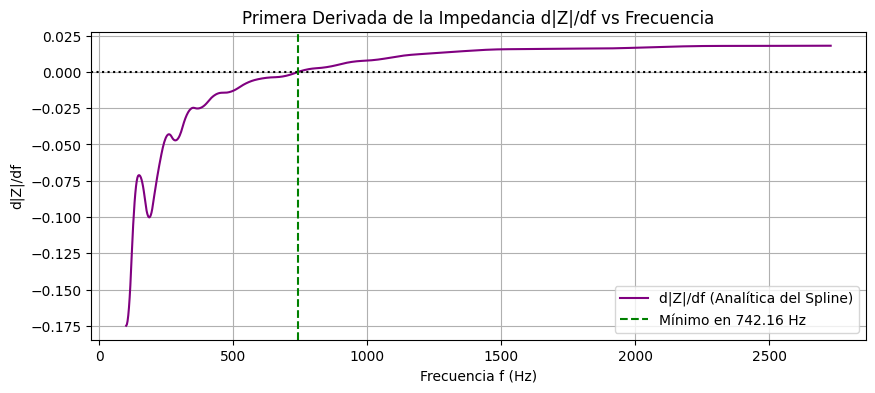


--- Resultados de Búsqueda de Raíces (Z_th = 150 Ohm) ---
Raíz 1 (Bisección): 113.6976 Hz | (Newton-Raphson): 113.6976 Hz
Raíz 2 (Bisección): 2216.7413 Hz | (Newton-Raphson): 2216.7413 Hz
Derivada d|Z|/df en Raíz 2: 0.0177
Sensibilidad df/d|Z| en Raíz 2: 56.4055 Hz/Ohm


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import bisect, newton
import random

# Configuración de reproducibilidad para la validación Leave-One-Out (LOO)
random.seed(42)
np.random.seed(42)

# ==========================================
# 0. CARGA DE DATOS
# ==========================================
f = np.array([
    100, 120, 145, 170, 200, 235, 270, 310, 355, 405,
    460, 520, 585, 655, 730, 810, 895, 985, 1080, 1180,
    1290, 1410, 1540, 1680, 1830, 1990, 2160, 2340, 2530, 2730
], dtype=float)

Z = np.array([
    152.3, 149.1, 146.8, 144.9, 142.0, 139.5, 137.9, 136.1, 134.8, 133.6,
    132.7, 131.9, 131.4, 131.1, 130.9, 131.0, 131.3, 131.9, 132.7, 133.8,
    135.2, 136.9, 138.9, 141.1, 143.5, 146.1, 149.0, 152.2, 155.6, 159.2
], dtype=float)

f_fine = np.linspace(f.min(), f.max(), 1000)

# ==========================================
# PARTE A - ANÁLISIS EXPLORATORIO
# ==========================================
plt.figure(figsize=(10, 5))
plt.scatter(f, Z, color='red', label='Datos Experimentales')
plt.title('Magnitud de Impedancia |Z| vs Frecuencia (f)')
plt.xlabel('Frecuencia f (Hz)')
plt.ylabel(r'Impedancia |Z| ($\Omega$)')
plt.grid(True, linestyle='--')
plt.legend()
plt.savefig('parte_a_exploratorio.png')
plt.show()

# Estimación visual del mínimo
idx_min_vis = np.argmin(Z)
print(f"Parte A: Mínimo visual aproximado en f = {f[idx_min_vis]} Hz con |Z| = {Z[idx_min_vis]} Ohm")

# ==========================================
# PARTE B1 - INTERPOLACIÓN POLINÓMICA Y FENÓMENO DE RUNGE
# ==========================================
degrees = [5, 10, 15, 29]
plt.figure(figsize=(12, 6))
plt.scatter(f, Z, color='red', zorder=5, label='Datos')

for d in degrees:
    p_coefs = np.polyfit(f, Z, d)
    z_poly = np.polyval(p_coefs, f_fine)
    plt.plot(f_fine, z_poly, label=f'Polinomio Grado {d}')

plt.ylim(100, 200)
plt.title('Interpolación Polinómica - Evidencia de Oscilaciones de Runge')
plt.xlabel('Frecuencia f (Hz)')
plt.ylabel(r'|Z| ($\Omega$)') # CORRECCIÓN: string crudo 'r'
plt.legend()
plt.grid(True)
plt.savefig('parte_b1_runge.png')
plt.show()

# Validación Leave-One-Out (LOO) con 5 puntos aleatorios para Grado 5
idx_loo = random.sample(range(len(f)), 5)
errors = []

print("\n--- Validación Leave-One-Out (LOO) para Grado 5 ---")
for idx in idx_loo:
    f_train = np.delete(f, idx)
    Z_train = np.delete(Z, idx)

    poly_train = np.polyfit(f_train, Z_train, 5)

    Z_pred = np.polyval(poly_train, f[idx])
    err_rel = abs(Z_pred - Z[idx]) / Z[idx]
    errors.append(err_rel)
    print(f"Excluyendo f={f[idx]} Hz: Real={Z[idx]}, Pred={Z_pred:.4f}, Error Rel={err_rel:.6%}")

print(f"Error Relativo Medio Estimado (LOO): {np.mean(errors):.6%}")

# Predicción en f = 1000 Hz con polinomio de Grado 5
poly_selected = np.polyfit(f, Z, 5)
Z_1000_poly = np.polyval(poly_selected, 1000)
print(f"Predicción Polinómica (Grado 5) en 1000 Hz: {Z_1000_poly:.4f} Ohm")

# ==========================================
# PARTE B2 & C - SPLINES CÚBICOS Y DERIVACIÓN
# ==========================================
spline = CubicSpline(f, Z, bc_type='natural')

Z_1000_spline = spline(1000)
print(f"\nPredicción Spline Cúbico en 1000 Hz: {Z_1000_spline:.4f} Ohm")

# Derivadas analíticas obtenidas del Spline
spline_d1 = spline.derivative(1)
spline_d2 = spline.derivative(2)

Z_fine_spline = spline(f_fine)
d1_fine = spline_d1(f_fine)

# Gráfico Comparativo de Interpolaciones
plt.figure(figsize=(10, 5))
plt.scatter(f, Z, color='red', label='Datos')
plt.plot(f_fine, np.polyval(poly_selected, f_fine), '--', label='Polinomio Grado 5')
plt.plot(f_fine, Z_fine_spline, label='Spline Cúbico Natural')
plt.title('Comparativa: Polinomio Seleccionado vs Spline Cúbico')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel(r'|Z| ($\Omega$)')
plt.legend()
plt.grid(True)
plt.savefig('parte_b2_comparativa.png')
plt.show()

# Encontrar el cero de la primera derivada para hallar el mínimo exacto
f_min_exact = newton(spline_d1, 730.0)
Z_min_exact = spline(f_min_exact)
d2_at_min = spline_d2(f_min_exact)

print(f"\n--- Resultados de Derivación Numérica (Parte C) ---")
print(f"Ubicación exacta del mínimo: f = {f_min_exact:.4f} Hz")
print(f"Valor de impedancia mínimo: |Z| = {Z_min_exact:.4f} Ohm")
print(f"Segunda derivada en el mínimo: {d2_at_min:.4f}")

# Gráfico de la primera derivada
plt.figure(figsize=(10, 4))
plt.plot(f_fine, d1_fine, color='purple', label="d|Z|/df (Analítica del Spline)")
plt.axhline(0, color='black', linestyle=':')
plt.axvline(f_min_exact, color='green', linestyle='--', label=f'Mínimo en {f_min_exact:.2f} Hz')
plt.title('Primera Derivada de la Impedancia d|Z|/df vs Frecuencia')
plt.xlabel('Frecuencia f (Hz)')
plt.ylabel('d|Z|/df')
plt.legend()
plt.grid(True)
plt.savefig('parte_c_derivada.png')
plt.show()

# ==========================================
# PARTE D - BÚSQUEDA DE RAÍCES
# ==========================================
Z_th = 150.0
def root_func(freq):
    return spline(freq) - Z_th

root1_bis = bisect(root_func, 100, 120, xtol=1e-5)
root2_bis = bisect(root_func, 2160, 2340, xtol=1e-5)

root1_nw = newton(root_func, 110)
root2_nw = newton(root_func, 2200)

print(f"\n--- Resultados de Búsqueda de Raíces (Z_th = 150 Ohm) ---")
print(f"Raíz 1 (Bisección): {root1_bis:.4f} Hz | (Newton-Raphson): {root1_nw:.4f} Hz")
print(f"Raíz 2 (Bisección): {root2_bis:.4f} Hz | (Newton-Raphson): {root2_nw:.4f} Hz")

# Sensibilidad y estabilidad en la raíz cercana a 2000 Hz (Raíz 2)
dZ_df_at_r2 = spline_d1(root2_nw)
df_dZ_at_r2 = 1.0 / dZ_df_at_r2
print(f"Derivada d|Z|/df en Raíz 2: {dZ_df_at_r2:.4f}")
print(f"Sensibilidad df/d|Z| en Raíz 2: {df_dZ_at_r2:.4f} Hz/Ohm")